# **Imports**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ------------------------------------------
# desabilita warnings
# ------------------------------------------
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ------------------------------------------
# bibliotecas principais
# ------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [5]:
df = pd.read_csv('/content/drive/Shareddrives/grupo4-rappi-hour/bases-rappi/df-oficial.csv')

In [6]:
df = df.drop(columns = ['TIME_DELTA_treated', 'Unnamed: 0', 'GENERO'])

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157627 entries, 0 to 157626
Data columns (total 32 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   IS_ACTIVE                          157627 non-null  int64  
 1   TRANSPORTE                         157627 non-null  int64  
 2   AUTO_ACEITE                        157627 non-null  int64  
 3   GORJETA                            157627 non-null  float64
 4   FRETE_MEDIO                        157627 non-null  float64
 5   COOKING_TIME_MEDIO                 157627 non-null  float64
 6   ITENS_MEDIO                        157627 non-null  float64
 7   DISTANCE_TO_USER                   157627 non-null  float64
 8   ORDERS_DONE                        157627 non-null  float64
 9   ORDERS_CANCEL                      157627 non-null  float64
 10  CANCELS_OPS_RT                     157627 non-null  float64
 11  ORDERS                             1576

## Features / Target


In [7]:
x = df.drop(columns="IS_ACTIVE") # features
y = df["IS_ACTIVE"] # target

In [8]:
from sklearn.model_selection import train_test_split


In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                    test_size = 0.3, 
                                                    random_state = 1)

In [10]:
from sklearn.preprocessing import MinMaxScaler

# Instaciando o objeto scaler
scaler = MinMaxScaler()

# Fit + transform no conjunto de treino
# Utilizando explicitamente as colunas de ambos os lados força que o
# resultado da normalização ainda seja o dataframe (muito mais facil de manipular) e não um numpy array
x_train[list(x_train.columns)] = scaler.fit_transform(x_train[list(x_train.columns)])

# Agora utilizando o scaler no conjunto de teste
# Utilizar apenas o transform, pois fit é só no conjunto de treino,]
# o conjunto de teste é utilizado para medir a capacidade de generalização do modelo no mundo real (dados não vistos)
# então faz sentido que a mesma normalização treinada e submetida ao conjunto de treino seja apenas aplicada no de teste
x_test[list(x_test.columns)] = scaler.transform(x_test[list(x_test.columns)])

In [11]:
y_train.squeeze()

914       1
44068     2
74391     2
114477    2
117734    1
         ..
73349     2
109259    2
50057     2
5192      1
128037    2
Name: IS_ACTIVE, Length: 110338, dtype: int64

In [12]:
y_true = y_test

# **Models**

## Logistic Regression


In [13]:
from sklearn.linear_model import LogisticRegression

# Instaciação do obj Algoritmo
logreg = LogisticRegression()
# Treino # x = Features, y = Label/Target
logreg.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

LogisticRegression()

In [14]:
print('Acuracidade (treino): ', logreg.score( x_train, y_train ))
print('Acuracidade (teste): ', logreg.score( x_test, y_test ))

Acuracidade (treino):  0.93886059199913
Acuracidade (teste):  0.9369197910719195


In [15]:
y_pred_logreg = logreg.predict(x_test)

In [16]:
cm_logreg = confusion_matrix(y_true, y_pred_logreg, normalize = 'true')
cm_logreg

array([[9.92883180e-01, 3.47161951e-04, 6.76965805e-03],
       [0.00000000e+00, 8.06651732e-01, 1.93348268e-01],
       [3.34202259e-05, 2.32938975e-02, 9.76672682e-01]])

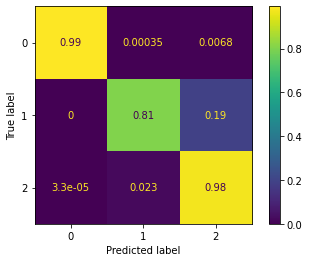

In [17]:
# versão visual mais bonita da matriz
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, 
                              display_labels=logreg.classes_)

disp_logreg.plot()
plt.show()

In [18]:
print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5761
           1       0.93      0.81      0.86     11606
           2       0.93      0.98      0.95     29922

    accuracy                           0.94     47289
   macro avg       0.95      0.93      0.94     47289
weighted avg       0.94      0.94      0.94     47289



Feature: 0, Score: 1.94748
Feature: 1, Score: 0.35427
Feature: 2, Score: 0.26187
Feature: 3, Score: -0.59536
Feature: 4, Score: -0.78708
Feature: 5, Score: -0.94015
Feature: 6, Score: -1.04131
Feature: 7, Score: 0.49114
Feature: 8, Score: 2.11096
Feature: 9, Score: -1.03276
Feature: 10, Score: -0.27618
Feature: 11, Score: 0.01768
Feature: 12, Score: -0.82426
Feature: 13, Score: -0.08793
Feature: 14, Score: 0.82241
Feature: 15, Score: 0.82596
Feature: 16, Score: 0.20443
Feature: 17, Score: 0.41586
Feature: 18, Score: -0.48362
Feature: 19, Score: 0.06348
Feature: 20, Score: -0.51413
Feature: 21, Score: 0.47343
Feature: 22, Score: 2.98135
Feature: 23, Score: -0.30584
Feature: 24, Score: 0.74693
Feature: 25, Score: -0.05661
Feature: 26, Score: -0.72689
Feature: 27, Score: -1.29112
Feature: 28, Score: -2.15156
Feature: 29, Score: -1.96319
Feature: 30, Score: -1.53399
Feature: 31, Score: -0.13898
Feature: 32, Score: 6.78915


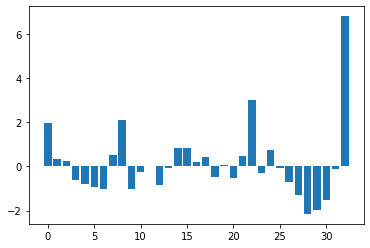

In [120]:
importance = logreg.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x for x in range(len(importance))], importance)
plt.show()

## Adaboost



In [19]:
#from sklearn.ensemble import AdaBoostClassifier

# Instaciação do obj Algoritmo
#adaboost = AdaBoostClassifier()
# Treino # x = Features, y = Label/Target
#adaboost.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [20]:
#print('Acuracidade (treino): ', adaboost.score( x_train, y_train ))
#print('Acuracidade (teste): ', adaboost.score( x_test, y_test ))

In [21]:
#y_pred_adaboost = adaboost.predict(x_test)

In [22]:
#cm_adaboost = confusion_matrix(y_true, y_pred_adaboost, normalize = 'true')
#cm_adaboost

In [23]:
# versão visual mais bonita da matriz
#disp_adaboost = ConfusionMatrixDisplay(confusion_matrix=cm_adaboost, 
#                              display_labels=adaboost.classes_)

#disp_adaboost.plot()
#plt.show()

In [24]:
#print(classification_report(y_test, y_pred_adaboost))

## Random Forest


In [25]:
#from sklearn.ensemble import RandomForestClassifier

# Instaciação do obj Algoritmo
#ranfor = RandomForestClassifier()
# Treino # x = Features, y = Label/Target
#ranfor.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [26]:
#print('Acuracidade (treino): ', ranfor.score( x_train, y_train ))
#print('Acuracidade (teste): ', ranfor.score( x_test, y_test ))

In [27]:
#y_pred_ranfor = ranfor.predict(x_test)

In [28]:
#cm_ranfor = confusion_matrix(y_true, y_pred_ranfor, normalize = 'true')
#cm_ranfor

In [29]:
# versão visual mais bonita da matriz
#disp_ranfor = ConfusionMatrixDisplay(confusion_matrix=cm_ranfor, 
#                              display_labels=ranfor.classes_)

#disp_ranfor.plot()
#plt.show()

In [30]:
#print(classification_report(y_test, y_pred_ranfor))

## SGD


In [31]:
#from sklearn.linear_model import SGDClassifier

# Instaciação do obj Algoritmo
#sgd = SGDClassifier()
# Treino # x = Features, y = Label/Target
#sgd.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [32]:
#print('Acuracidade (treino): ', sgd.score( x_train, y_train ))
#print('Acuracidade (teste): ', sgd.score( x_test, y_test ))

In [33]:
#y_pred_sgd = sgd.predict(x_test)

In [34]:
#cm_sgd = confusion_matrix(y_true, y_pred_sgd, normalize = 'true')
#cm_sgd

In [35]:
# versão visual mais bonita da matriz
#disp_sgd = ConfusionMatrixDisplay(confusion_matrix=cm_sgd, 
#                              display_labels=sgd.classes_)

#disp_sgd.plot()
#plt.show()

In [36]:
#print(classification_report(y_test, y_pred_sgd))

## SVM


In [37]:
#from sklearn import svm

# Instaciação do obj Algoritmo
#svm = svm.SVC()
# Treino # x = Features, y = Label/Target
#svm.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [38]:
#print('Acuracidade (treino): ', svm.score( x_train, y_train ))
#print('Acuracidade (teste): ', svm.score( x_test, y_test ))

In [39]:
#y_pred_svm = svm.predict(x_test)

In [40]:
#cm_svm = confusion_matrix(y_true, y_pred_svm, normalize = 'true')
#cm_svm

In [41]:
# versão visual mais bonita da matriz
#disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, 
#                              display_labels=svm.classes_)

#disp_svm.plot()
#plt.show()

In [42]:
#print(classification_report(y_test, y_pred_svm))

In [43]:
from sklearn.neighbors import KNeighborsClassifier

# Instaciação do obj Algoritmo
knn = KNeighborsClassifier(n_neighbors=5)
# Treino # x = Features, y = Label/Target
knn.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

KNeighborsClassifier()

In [44]:
print('Acuracidade (treino): ', knn.score( x_train, y_train ))
print('Acuracidade (teste): ', knn.score( x_test, y_test ))

Acuracidade (treino):  0.9584458663379797
Acuracidade (teste):  0.9409587853411998


In [45]:
y_pred_knn = knn.predict(x_test)

In [46]:
cm_knn = confusion_matrix(y_true, y_pred_knn, normalize = 'true')
cm_knn

array([[0.99288318, 0.00138865, 0.00572817],
       [0.        , 0.86188179, 0.13811821],
       [0.        , 0.03836642, 0.96163358]])

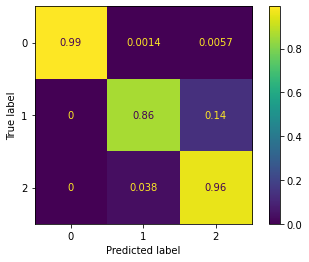

In [47]:
# versão visual mais bonita da matriz
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, 
                              display_labels=knn.classes_)

disp_knn.plot()
plt.show()

In [48]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5761
           1       0.90      0.86      0.88     11606
           2       0.95      0.96      0.95     29922

    accuracy                           0.94     47289
   macro avg       0.95      0.94      0.94     47289
weighted avg       0.94      0.94      0.94     47289



In [49]:
from sklearn.neighbors import KNeighborsClassifier

# Instaciação do obj Algoritmo
knn = KNeighborsClassifier(n_neighbors=5)
# Treino # x = Features, y = Label/Target
knn.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

KNeighborsClassifier()

## KNN


In [50]:
from sklearn.neighbors import KNeighborsClassifier

# Instaciação do obj Algoritmo
knn = KNeighborsClassifier(n_neighbors=5)
# Treino # x = Features, y = Label/Target
knn.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

KNeighborsClassifier()

In [51]:
print('Acuracidade (treino): ', knn.score( x_train, y_train ))
print('Acuracidade (teste): ', knn.score( x_test, y_test ))

Acuracidade (treino):  0.9584458663379797
Acuracidade (teste):  0.9409587853411998


In [52]:
y_pred_knn = knn.predict(x_test)

In [53]:
cm_knn = confusion_matrix(y_true, y_pred_knn, normalize = 'true')
cm_knn

array([[0.99288318, 0.00138865, 0.00572817],
       [0.        , 0.86188179, 0.13811821],
       [0.        , 0.03836642, 0.96163358]])

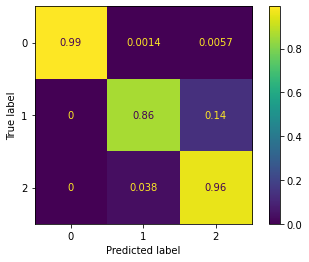

In [54]:
# versão visual mais bonita da matriz
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, 
                              display_labels=knn.classes_)

disp_knn.plot()
plt.show()

In [55]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5761
           1       0.90      0.86      0.88     11606
           2       0.95      0.96      0.95     29922

    accuracy                           0.94     47289
   macro avg       0.95      0.94      0.94     47289
weighted avg       0.94      0.94      0.94     47289



## LGBM


In [61]:
#import lightgbm as lgb

#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)
# Criando o modelo

#lgb = lgb.LGBMClassifier()

#lgb.fit(x_train, y_train)


LGBMClassifier()

In [62]:
#print('Acuracidade (treino): ', lgb.score( x_train, y_train ))
#print('Acuracidade (teste): ', lgb.score( x_test, y_test ))

Acuracidade (treino):  0.9850187605358082
Acuracidade (teste):  0.9838440229228784


In [63]:
#y_pred_lgb = lgb.predict(x_test)

In [64]:
#cm_lgb = confusion_matrix(y_true, y_pred_lgb, normalize = 'true')
#cm_lgb

array([[0.11872939, 0.25967714, 0.62159347],
       [0.12148889, 0.24849216, 0.63001896],
       [0.12101464, 0.25419424, 0.62479112]])

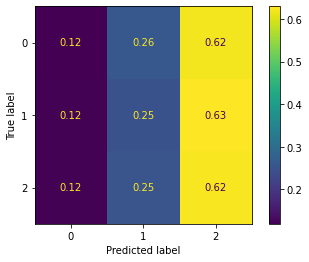

In [65]:
# versão visual mais bonita da matriz
#disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, 
#                              display_labels=lgb.classes_)

#disp_lgb.plot()
#plt.show()

In [66]:
#print(classification_report(y_test, y_pred_lgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5749
           1       0.95      0.99      0.97     11404
           2       1.00      0.98      0.99     30136

    accuracy                           0.98     47289
   macro avg       0.98      0.99      0.98     47289
weighted avg       0.98      0.98      0.98     47289



# 

# **Cluster Resample**

In [67]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=13)
x_resampled, y_resampled = rus.fit_resample(x, y)

In [68]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y, 
                                                    test_size = 0.3, 
                                                    random_state = 8)

In [69]:
# Instaciando o objeto scaler
scaler = MinMaxScaler()

# Fit + transform no conjunto de treino
# Utilizando explicitamente as colunas de ambos os lados força que o
# resultado da normalização ainda seja o dataframe (muito mais facil de manipular) e não um numpy array
x_train1[list(x_train1.columns)] = scaler.fit_transform(x_train1[list(x_train1.columns)])

# Agora utilizando o scaler no conjunto de teste
# Utilizar apenas o transform, pois fit é só no conjunto de treino,]
# o conjunto de teste é utilizado para medir a capacidade de generalização do modelo no mundo real (dados não vistos)
# então faz sentido que a mesma normalização treinada e submetida ao conjunto de treino seja apenas aplicada no de teste
x_test1[list(x_test1.columns)] = scaler.transform(x_test1[list(x_test1.columns)])

In [70]:
y_train1.squeeze()

108171    1
29555     2
78086     2
57660     2
10507     2
         ..
141448    0
62426     2
149489    0
25940     1
70083     2
Name: IS_ACTIVE, Length: 110338, dtype: int64

In [71]:
y_true1 = y_test1

## Logistic Regression


In [72]:
logreg.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

LogisticRegression()

In [73]:
print('Acuracidade (treino): ', logreg.score( x_train1, y_train1 ))
print('Acuracidade (teste): ', logreg.score( x_test1, y_test1 ))

Acuracidade (treino):  0.9399028439884718
Acuracidade (teste):  0.9385480767197445


In [74]:
y_pred_logreg = logreg.predict(x_test1)

In [75]:
cm_logreg = confusion_matrix(y_true1, y_pred_logreg, normalize = 'true')
cm_logreg

array([[9.94097222e-01, 3.47222222e-04, 5.55555556e-03],
       [0.00000000e+00, 8.15168786e-01, 1.84831214e-01],
       [0.00000000e+00, 2.53618377e-02, 9.74638162e-01]])

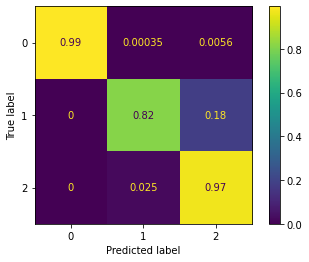

In [76]:
# versão visual mais bonita da matriz
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, 
                              display_labels=logreg.classes_)

disp_logreg.plot()
plt.show()

In [77]:
print(classification_report(y_test1, y_pred_logreg))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5760
           1       0.92      0.82      0.87     11405
           2       0.93      0.97      0.95     30124

    accuracy                           0.94     47289
   macro avg       0.95      0.93      0.94     47289
weighted avg       0.94      0.94      0.94     47289



Feature: 0, Score: 1.94748
Feature: 1, Score: 0.35427
Feature: 2, Score: 0.26187
Feature: 3, Score: -0.59536
Feature: 4, Score: -0.78708
Feature: 5, Score: -0.94015
Feature: 6, Score: -1.04131
Feature: 7, Score: 0.49114
Feature: 8, Score: 2.11096
Feature: 9, Score: -1.03276
Feature: 10, Score: -0.27618
Feature: 11, Score: 0.01768
Feature: 12, Score: -0.82426
Feature: 13, Score: -0.08793
Feature: 14, Score: 0.82241
Feature: 15, Score: 0.82596
Feature: 16, Score: 0.20443
Feature: 17, Score: 0.41586
Feature: 18, Score: -0.48362
Feature: 19, Score: 0.06348
Feature: 20, Score: -0.51413
Feature: 21, Score: 0.47343
Feature: 22, Score: 2.98135
Feature: 23, Score: -0.30584
Feature: 24, Score: 0.74693
Feature: 25, Score: -0.05661
Feature: 26, Score: -0.72689
Feature: 27, Score: -1.29112
Feature: 28, Score: -2.15156
Feature: 29, Score: -1.96319
Feature: 30, Score: -1.53399
Feature: 31, Score: -0.13898
Feature: 32, Score: 6.78915


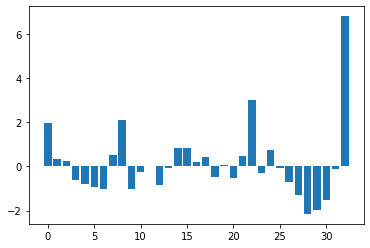

In [121]:
importance = logreg.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x_resampled for x_resampled in range(len(importance))], importance)
plt.show()

## Adaboost



In [78]:
#adaboost.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [79]:
#print('Acuracidade (treino): ', adaboost.score( x_train1, y_train1 ))
#print('Acuracidade (teste): ', adaboost.score( x_test1, y_test1 ))

In [80]:
#y_pred_adaboost = adaboost.predict(x_test1)

In [81]:
#cm_adaboost = confusion_matrix(y_true1, y_pred_adaboost, normalize = 'true')
#cm_adaboost

In [82]:
# versão visual mais bonita da matriz
#disp_adaboost = ConfusionMatrixDisplay(confusion_matrix=cm_adaboost, 
#                              display_labels=adaboost.classes_)

#disp_adaboost.plot()
#plt.show()

In [83]:
#print(classification_report(y_test1, y_pred_adaboost))

## Random Forest


In [84]:
#ranfor.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [85]:
#print('Acuracidade (treino): ', ranfor.score( x_train1, y_train1 ))
#print('Acuracidade (teste): ', ranfor.score( x_test1, y_test1 ))

In [86]:
#y_pred_ranfor = ranfor.predict(x_test1)

In [87]:
#cm_ranfor = confusion_matrix(y_true1, y_pred_ranfor, normalize = 'true')
#cm_ranfor

In [88]:
# versão visual mais bonita da matriz
#disp_ranfor = ConfusionMatrixDisplay(confusion_matrix=cm_ranfor, 
#                              display_labels=ranfor.classes_)

#disp_ranfor.plot()
#plt.show()

In [89]:
#print(classification_report(y_test1, y_pred_ranfor))

## SGD


In [90]:
#sgd.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [91]:
#print('Acuracidade (treino): ', sgd.score( x_train1, y_train1 ))
#print('Acuracidade (teste): ', sgd.score( x_test1, y_test1 ))

In [92]:
#y_pred_sgd = sgd.predict(x_test1)

In [93]:
#cm_sgd = confusion_matrix(y_true1, y_pred_sgd, normalize = 'true')
#cm_sgd

In [94]:
# versão visual mais bonita da matriz
#disp_sgd = ConfusionMatrixDisplay(confusion_matrix=cm_sgd, 
#                              display_labels=sgd.classes_)

#disp_sgd.plot()
#plt.show()

In [95]:
#print(classification_report(y_test1, y_pred_sgd))

## LGB

In [96]:
#lgb.fit(x_train1, y_train1)

LGBMClassifier()

In [97]:
#print('Acuracidade (treino): ', lgb.score( x_train1, y_train1 ))
#print('Acuracidade (teste): ', lgb.score( x_test1, y_test1 ))

Acuracidade (treino):  0.9853994090884374
Acuracidade (teste):  0.9825540823447313


In [98]:
#y_pred_lgb = lgb.predict(x_test1)

In [99]:
#cm_lgb = confusion_matrix(y_true1, y_pred_lgb, normalize = 'true')
#cm_lgb

array([[9.94097222e-01, 1.21527778e-03, 4.68750000e-03],
       [2.63042525e-04, 9.90881192e-01, 8.85576502e-03],
       [6.63922454e-05, 2.27393440e-02, 9.77194264e-01]])

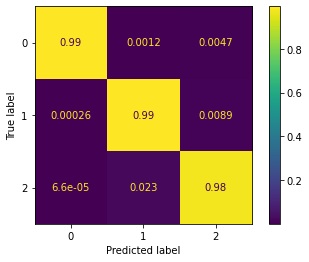

In [100]:
# versão visual mais bonita da matriz
#disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, 
#                              display_labels=lgb.classes_)

#disp_lgb.plot()
#plt.show()

In [101]:
#print(classification_report(y_test1, y_pred_lgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5760
           1       0.94      0.99      0.97     11405
           2       1.00      0.98      0.99     30124

    accuracy                           0.98     47289
   macro avg       0.98      0.99      0.98     47289
weighted avg       0.98      0.98      0.98     47289



## KNN


In [102]:
from sklearn.neighbors import KNeighborsClassifier

# Instaciação do obj Algoritmo
knn = KNeighborsClassifier(n_neighbors= 21)
# Treino # x = Features, y = Label/Target
knn.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

KNeighborsClassifier(n_neighbors=21)

In [103]:
print('Acuracidade (treino): ', knn.score( x_train1, y_train1 ))
print('Acuracidade (teste): ', knn.score( x_test1, y_test1 ))

Acuracidade (treino):  0.9357519621526582
Acuracidade (teste):  0.9290321216350526


In [104]:
y_pred_knn = knn.predict(x_test1)

In [105]:
cm_knn = confusion_matrix(y_true1, y_pred_knn, normalize = 'true')
cm_knn

array([[0.99409722, 0.00138889, 0.00451389],
       [0.        , 0.80771591, 0.19228409],
       [0.        , 0.03747842, 0.96252158]])

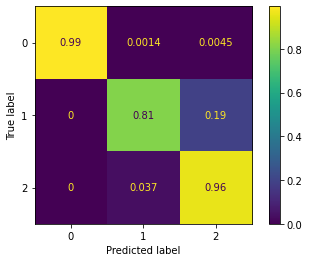

In [106]:
# versão visual mais bonita da matriz
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, 
                              display_labels=knn.classes_)

disp_knn.plot()
plt.show()

In [107]:
print(classification_report(y_test1, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5760
           1       0.89      0.81      0.85     11405
           2       0.93      0.96      0.95     30124

    accuracy                           0.93     47289
   macro avg       0.94      0.92      0.93     47289
weighted avg       0.93      0.93      0.93     47289



## SVM


In [109]:
#svm.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [110]:
#print('Acuracidade (treino): ', svm.score( x_train1, y_train1 ))
#print('Acuracidade (teste): ', svm.score( x_test1, y_test1 ))

In [111]:
#y_pred_svm = svm.predict(x_test1)

In [112]:
#cm_svm = confusion_matrix(y_true1, y_pred_svm, normalize = 'true')
#cm_svm

In [113]:
# versão visual mais bonita da matriz
#disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, 
#                              display_labels=svm.classes_)

#disp_svm.plot()
#plt.show()

IndentationError: ignored

In [ ]:
#print(classification_report(y_test1, y_pred_svm))